# Sales & Demand Forecasting for Businesses

**Machine Learning Internship - Task 1**
*Future Interns | Track Code: ML | Repository: FUTURE_ML_01*

---

### Author
**Rohit Kumar Malik** - AI & Cybersecurity Graduate

- LinkedIn: https://www.linkedin.com/in/rohitmalik7
- GitHub: https://github.com/RohitMalik7
- Email: rohitmalik180904@gmail.com

---

### Project Objective
This project builds a **sales forecasting system** using historical retail data.
The goal is not only to predict future sales accurately, but to present the
results in a clear, business-friendly way that a store owner, startup founder,
or business manager could use to plan **inventory, staffing, and cash flow**.

### Dataset Overview
| Property | Detail |
|----------|--------|
| Source | Superstore Sales Dataset (Kaggle) |
| Records | 9,994 orders |
| Columns | 21 |
| Time Period | January 2014 – December 2017 (4 full years) |
| Region | United States (4 regions: East, West, Central, South) |
| Key Columns | Order Date, Sales, Region, Category, Sub-Category, Segment, Profit |
| Data Quality | No missing values, no duplicate rows |

The data shows a clear **upward sales trend** along with strong **yearly
seasonality** - sales consistently peak in Q4 (Sep, Nov, Dec) and dip in
February. This makes it well suited for demand forecasting.

### Approach
1. Aggregate daily orders into a monthly sales time series
2. Explore trends and seasonality (EDA + time-series decomposition)
3. Engineer time-based and lag features
4. Build a baseline model, then a machine learning model (Random Forest / XGBoost)
5. Evaluate against the baseline and forecast future sales
6. Translate the forecast into clear business insights

## Phase 1 - Setup & Project Structure

We first import the core libraries and programmatically create a clean,
reproducible folder structure. Building the folders in code (rather than by
hand) is a professional convention - anyone can re-run this notebook and get
the exact same project layout.

In [1]:
# ---------- Core Libraries ----------
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display & plot settings for a clean, professional look
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13

# ---------- Project Folder Structure ----------
PROJECT = "FUTURE_ML_01"

folders = [
    f"{PROJECT}/data/raw",         # original dataset (never edited)
    f"{PROJECT}/data/processed",   # cleaned / aggregated data
    f"{PROJECT}/notebooks",        # this notebook
    f"{PROJECT}/reports/figures",  # exported charts for README & LinkedIn
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created successfully:\n")
for folder in folders:
    print("  -", folder)

Project structure created successfully:

  - FUTURE_ML_01/data/raw
  - FUTURE_ML_01/data/processed
  - FUTURE_ML_01/notebooks
  - FUTURE_ML_01/reports/figures


## Phase 2 - Loading the Dataset

The dataset can be loaded in two ways. Choose whichever suits your setup:

- **Option 1 - Google Drive:** if you've saved the CSV to your Drive
  (good for re-running the notebook later without re-uploading).
- **Option 2 - Local Upload (active):** upload the CSV directly from your
  computer for this session.

**Note:** the Superstore file is `latin-1` encoded (not UTF-8), so we set
`encoding="latin-1"` to load it without errors.

In [2]:
# ===================== OPTION 1: Load from Google Drive =====================
# Uncomment the 3 lines below if your CSV is saved in Google Drive.
#
# from google.colab import drive
# drive.mount('/content/drive')
# csv_path = '/content/drive/MyDrive/Sample - Superstore.csv'   # adjust path if needed


# ===================== OPTION 2: Upload from Local Machine (ACTIVE) ==========
from google.colab import files
print("Please select your Superstore CSV from your computer:")
uploaded = files.upload()

# Automatically use whatever filename was uploaded (handles spaces, underscores, etc.)
csv_path = list(uploaded.keys())[0]
print("File received:", csv_path)


# ---------- Load the dataset ----------
# 'latin-1' encoding is required for this dataset (it fails with UTF-8)
df = pd.read_csv(csv_path, encoding="latin-1")

# ---------- Keep a clean copy of the raw file inside the project structure ----------
shutil.copy(csv_path, f"{PROJECT}/data/raw/Sample_-_Superstore.csv")

# ---------- Quick confirmation that the data loaded correctly ----------
print(f"\nDataset loaded successfully - shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.head()

Please select your Superstore CSV from your computer:


Saving Sample - Superstore.csv to Sample - Superstore (3).csv
File received: Sample - Superstore (3).csv

Dataset loaded successfully - shape: 9994 rows x 21 columns

Missing values: 0
Duplicate rows: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Phase 3 - Data Inspection

Before touching the data, we run a professional sanity check to fully
understand what we're working with: the structure and data types, a
statistical summary of the numeric columns, an overview of the categorical
columns, and a data-quality check for missing values and duplicates.

This step confirms the data is reliable and tells us exactly what cleaning
(if any) is needed.

In [3]:
# ---------- 1. Structure & Data Types ----------
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
df.info()

# ---------- 2. Statistical Summary (Numeric Columns) ----------
print("\n" + "=" * 60)
print("NUMERIC SUMMARY")
print("=" * 60)
display(df.describe().round(2))

# ---------- 3. Categorical Overview ----------
print("=" * 60)
print("CATEGORICAL OVERVIEW")
print("=" * 60)
for col in ["Segment", "Region", "Category", "Sub-Category", "Ship Mode"]:
    print(f"{col:<14}: {df[col].nunique():>2} unique  ->  {list(df[col].unique())[:5]}")

# ---------- 4. Data Quality Check ----------
print("\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   flo

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


CATEGORICAL OVERVIEW
Segment       :  3 unique  ->  ['Consumer', 'Corporate', 'Home Office']
Region        :  4 unique  ->  ['South', 'West', 'Central', 'East']
Category      :  3 unique  ->  ['Furniture', 'Office Supplies', 'Technology']
Sub-Category  : 17 unique  ->  ['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage']
Ship Mode     :  4 unique  ->  ['Second Class', 'Standard Class', 'First Class', 'Same Day']

DATA QUALITY CHECK
Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total duplicate rows: 0


## Phase 4 - Data Cleaning

The dataset is already high quality (no missing values, no duplicates), so
cleaning is light and targeted:

1. **Drop columns not useful for forecasting** - `Row ID` (just an index),
   `Postal Code` (a geographic ID, not predictive), and `Country` (a single
   value, "United States", so it carries no information).
2. **Convert date columns to datetime** - `Order Date` and `Ship Date` are
   stored as text; we convert them so we can work with them as real dates.
3. **Confirm the data types** to make sure everything is ready for analysis.

In [4]:
# ---------- 1. Drop columns not needed for forecasting ----------
# Row ID      -> just a row index, no analytical value
# Postal Code -> geographic identifier, not predictive of sales
# Country     -> single value ('United States'), adds no information
cols_to_drop = ["Row ID", "Postal Code", "Country"]
df = df.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)

# ---------- 2. Convert date columns to datetime ----------
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"]  = pd.to_datetime(df["Ship Date"])
print("Converted 'Order Date' and 'Ship Date' to datetime format.")

# ---------- 3. Confirm the cleaned structure ----------
print("\nColumns remaining:", df.shape[1])
print("Order Date range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())

print("\nUpdated data types:")
print(df.dtypes)

df.head()

Dropped columns: ['Row ID', 'Postal Code', 'Country']
Converted 'Order Date' and 'Ship Date' to datetime format.

Columns remaining: 18
Order Date range: 2014-01-03 to 2017-12-30

Updated data types:
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
City                     object
State                    object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Phase 5 - Aggregation (Building the Time Series)

The dataset contains 9,994 individual orders. For forecasting, we need a
**time series** - total sales per time period. We aggregate the orders into
**monthly total sales**, which turns the data into a clean 48-point series
(12 months × 4 years).

Monthly aggregation is the right level here: it smooths out daily noise while
keeping enough points to capture the yearly seasonal pattern. The result is
saved to `data/processed/` so the analysis is fully reproducible.

In [5]:
# ---------- Aggregate daily orders into a MONTHLY sales time series ----------
# 'MS' = Month Start frequency (groups all sales into calendar months)
monthly_sales = (
    df.set_index("Order Date")
      .resample("MS")["Sales"]
      .sum()
      .reset_index()
)
monthly_sales.columns = ["Month", "Sales"]

print("Monthly time series created.")
print("Number of months:", len(monthly_sales))
print("Date range:", monthly_sales["Month"].min().date(),
      "to", monthly_sales["Month"].max().date())

# ---------- Save the processed time series ----------
monthly_sales.to_csv(f"{PROJECT}/data/processed/monthly_sales.csv", index=False)
print("Saved -> data/processed/monthly_sales.csv")

monthly_sales.head()

Monthly time series created.
Number of months: 48
Date range: 2014-01-01 to 2017-12-01
Saved -> data/processed/monthly_sales.csv


,Month,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


## Phase 6 - Exploratory Data Analysis (EDA)

Now we explore the data visually to understand its behaviour before modelling.
We look at three things:

1. **Overall trend** - how monthly sales have moved over the 4 years.
2. **Seasonality** - a year-over-year overlay to reveal repeating yearly
   patterns.
3. **Business breakdown** - which Regions and Categories drive the most sales.

These charts are the foundation of the business story: a model is only useful
if we first understand the patterns it needs to learn.

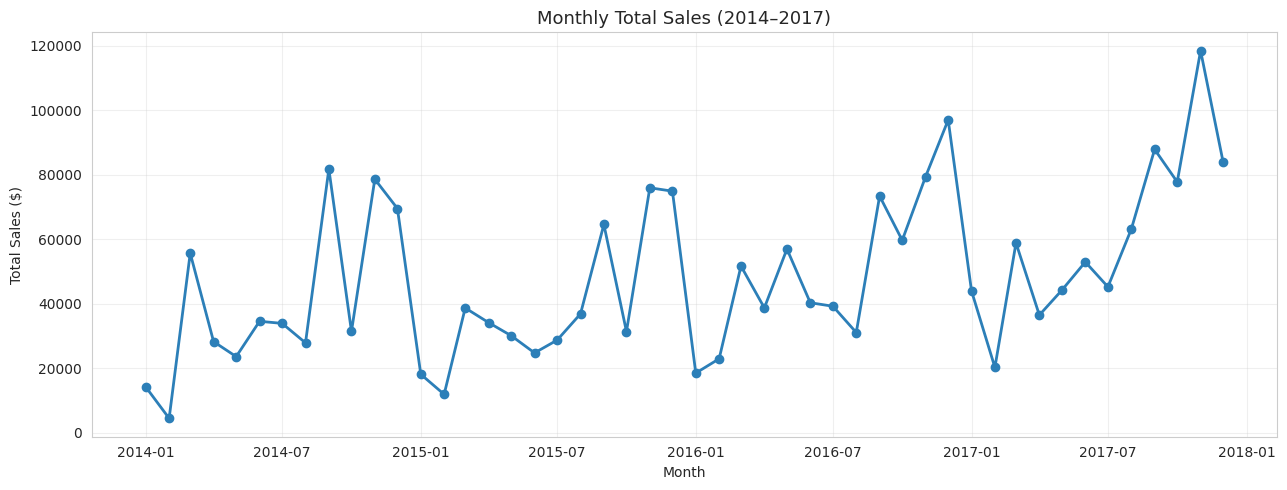

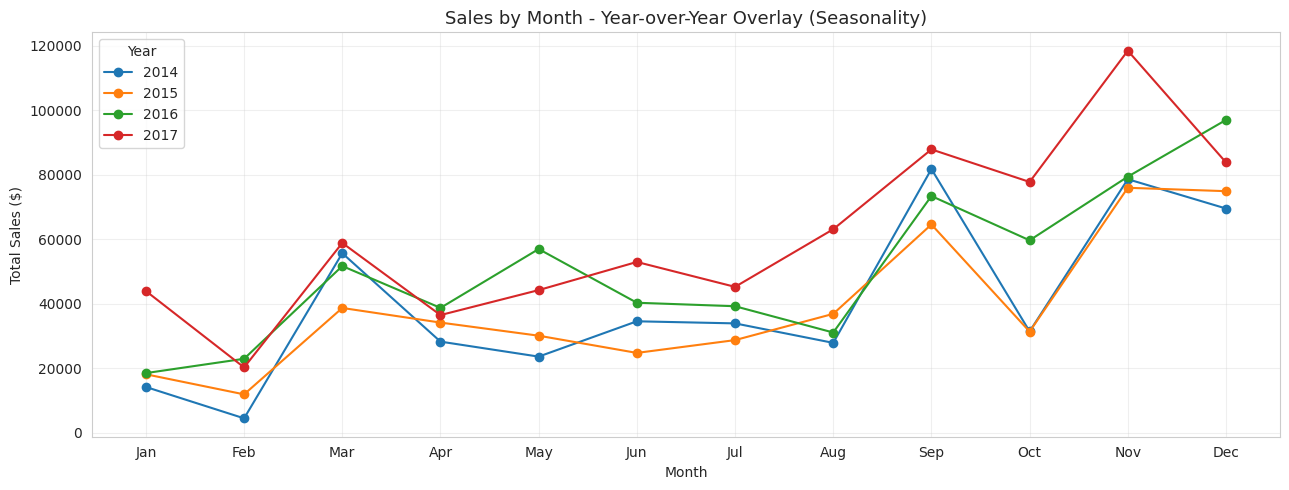

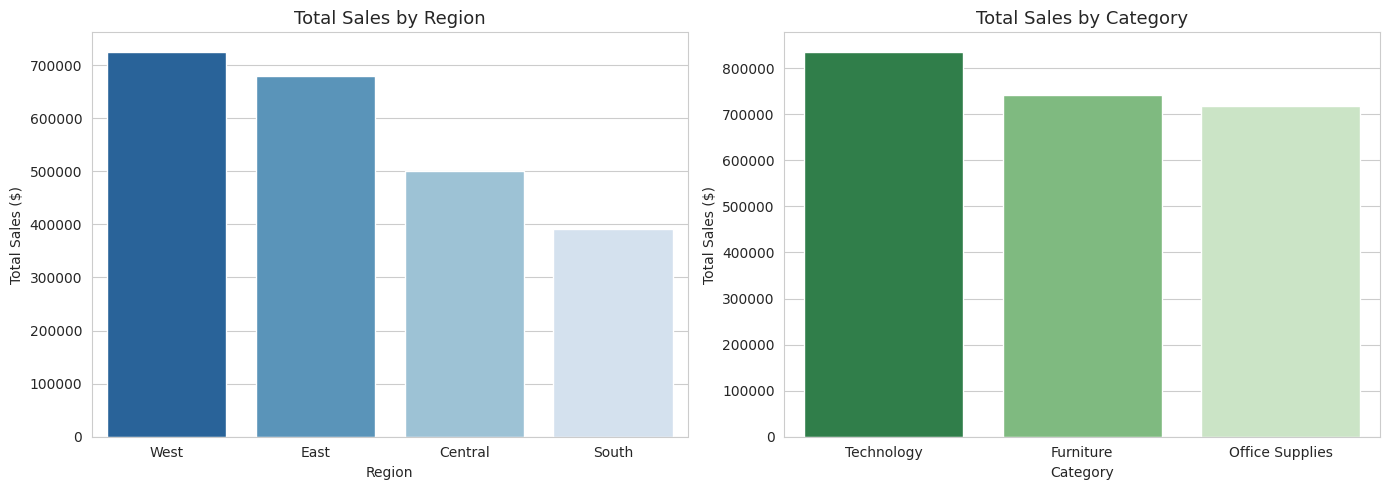

In [6]:
# ============================================================
# CHART 1 - Overall Monthly Sales Trend
# ============================================================
plt.figure(figsize=(13, 5))
plt.plot(monthly_sales["Month"], monthly_sales["Sales"],
         marker="o", linewidth=2, color="#2c7fb8")
plt.title("Monthly Total Sales (2014–2017)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/01_sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# CHART 2 - Year-over-Year Overlay (Seasonality)
# ============================================================
seasonal = monthly_sales.copy()
seasonal["Year"] = seasonal["Month"].dt.year
seasonal["MonthNum"] = seasonal["Month"].dt.month
pivot = seasonal.pivot(index="MonthNum", columns="Year", values="Sales")

plt.figure(figsize=(13, 5))
for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker="o", label=str(year))
plt.title("Sales by Month - Year-over-Year Overlay (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1, 13),
           ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/02_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# CHART 3 - Sales by Region and Category
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by Region
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values,
            hue=region_sales.index, palette="Blues_r", legend=False, ax=axes[0])
axes[0].set_title("Total Sales by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Total Sales ($)")

# Sales by Category
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values,
            hue=cat_sales.index, palette="Greens_r", legend=False, ax=axes[1])
axes[1].set_title("Total Sales by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/03_sales_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 7 - Time-Series Decomposition

Before modelling, we formally separate the time series into its three building
blocks to *prove* the patterns we spotted visually:

- **Trend** - the long-term direction (here, steadily rising sales).
- **Seasonal** - the repeating yearly pattern (Q4 peaks, February dips).
- **Residual** - what's left over (random noise the model can't explain).

We use an **additive model** with `period=12` (12 months = one seasonal
cycle). This confirms that our data has a clear, learnable seasonal structure -
exactly what a forecasting model needs.

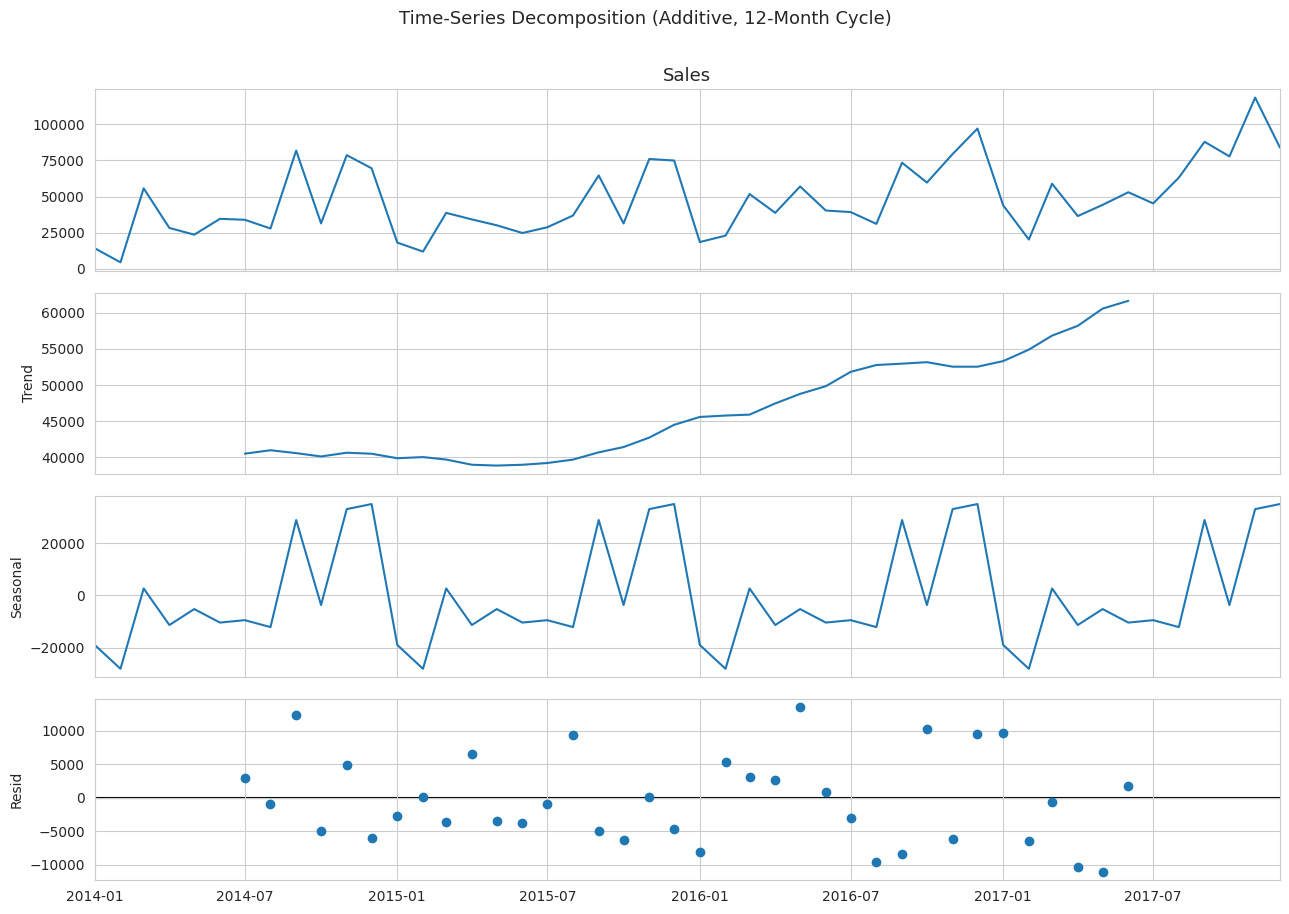

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Build a clean time-indexed series
ts = monthly_sales.set_index("Month")["Sales"]

# Decompose: additive model, 12-month seasonal cycle
decomposition = seasonal_decompose(ts, model="additive", period=12)

# Plot the four panels (observed, trend, seasonal, residual)
fig = decomposition.plot()
fig.set_size_inches(13, 9)
fig.suptitle("Time-Series Decomposition (Additive, 12-Month Cycle)",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/04_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 8 - Feature Engineering

Machine learning models can't read a date directly - we have to turn time into
useful numeric features. We create three types:

1. **Calendar features** - `Year`, `MonthNum`, `Quarter`. These let the model
   learn *when* in the year sales tend to be high or low (seasonality).
2. **Lag features** - sales from 1, 2, 3, and 12 months ago. The most recent
   months are strong predictors, and `lag_12` (same month last year) directly
   captures the yearly seasonal pattern.
3. **Rolling mean** - the average of the previous 3 months, which captures the
   recent trend/momentum. It's calculated on *past* values only, so there is
   **no data leakage**.

Because `lag_12` needs a full prior year, the first 12 rows have missing values
and are dropped - leaving **36 clean rows** ready for modelling. Losing one year
is a worthwhile trade for capturing yearly seasonality in data this seasonal.

In [8]:
# ---------- Build a feature-rich dataframe from the monthly series ----------
features = monthly_sales.copy()

# 1. Calendar (date-based) features
features["Year"]     = features["Month"].dt.year
features["MonthNum"] = features["Month"].dt.month
features["Quarter"]  = features["Month"].dt.quarter

# 2. Lag features - past sales the model can learn from
for lag in [1, 2, 3, 12]:
    features[f"lag_{lag}"] = features["Sales"].shift(lag)

# 3. Rolling mean of the previous 3 months
#    .shift(1) first ensures we only use PAST months -> no data leakage
features["rolling_mean_3"] = features["Sales"].shift(1).rolling(window=3).mean()

# ---------- Drop rows with NaNs created by the lags (the first 12 months) ----------
features_clean = features.dropna().reset_index(drop=True)

print("Rows before dropping lag NaNs:", len(features))
print("Rows after  dropping lag NaNs:", len(features_clean))
print("\nFeature columns used for modelling:")
print([c for c in features_clean.columns if c not in ["Month", "Sales"]])

# ---------- Save the model-ready feature table ----------
features_clean.to_csv(f"{PROJECT}/data/processed/model_features.csv", index=False)
print("\nSaved -> data/processed/model_features.csv")

features_clean.head()

Rows before dropping lag NaNs: 48
Rows after  dropping lag NaNs: 36

Feature columns used for modelling:
['Year', 'MonthNum', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_mean_3']

Saved -> data/processed/model_features.csv


,Month,Sales,Year,MonthNum,Quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3
0,2015-01-01,18174.0756,2015,1,1,69545.6205,78628.7167,31453.3930,14236.895,59875.910067
1,2015-02-01,11951.4110,2015,2,1,18174.0756,69545.6205,78628.7167,4519.892,55449.470933
2,2015-03-01,38726.2520,2015,3,1,11951.4110,18174.0756,69545.6205,55691.009,33223.702367
3,2015-04-01,34195.2085,2015,4,2,38726.2520,11951.4110,18174.0756,28295.345,22950.579533
4,2015-05-01,30131.6865,2015,5,2,34195.2085,38726.2520,11951.4110,23648.287,28290.957167


## Phase 9 - Train / Test Split

For time-series data we **never shuffle**. Shuffling would let the model "see"
future months while training on the past, leaking the answer and giving a
falsely good score. Instead we split **by time**: train on the earlier months,
test on the most recent ones.

We have 36 feature rows (the first year was consumed by `lag_12`). We hold out
the **last 6 months as the test set**, leaving **30 months for training**.
Conveniently, the test period (Jul–Dec 2017) includes the Q4 sales peak - a
realistic, demanding test of whether the model has truly learned the
seasonality.

In [9]:
# ---------- Define features (X) and target (y) ----------
feature_cols = ["Year", "MonthNum", "Quarter",
                "lag_1", "lag_2", "lag_3", "lag_12", "rolling_mean_3"]

X = features_clean[feature_cols]
y = features_clean["Sales"]

# ---------- Time-based split (NO shuffle) ----------
TEST_SIZE = 6   # hold out the last 6 months
X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

# Keep the matching dates for plotting later
train_dates = features_clean["Month"].iloc[:-TEST_SIZE]
test_dates  = features_clean["Month"].iloc[-TEST_SIZE:]

print("Training period:", train_dates.min().date(), "to", train_dates.max().date(),
      f"({len(X_train)} months)")
print("Testing  period:", test_dates.min().date(), "to", test_dates.max().date(),
      f"({len(X_test)} months)")

Training period: 2015-01-01 to 2017-06-01 (30 months)
Testing  period: 2017-07-01 to 2017-12-01 (6 months)


## Phase 10 - Baseline Model

Before building anything fancy, a professional always establishes a **baseline**
- a simple, no-machine-learning prediction. If our model can't beat the
baseline, it isn't adding value.

Our baseline is the **naive forecast**: predict each month's sales to be the
same as the *previous* month. It's the simplest possible benchmark.

We also define a reusable `evaluate()` function that reports three metrics:
- **MAE** - average error in dollars (easy to explain to a business).
- **RMSE** - like MAE but punishes large misses more.
- **MAPE** - average error as a percentage (great for business communication).

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------- Reusable evaluation function (used for every model) ----------
def evaluate(y_true, y_pred, label):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:<22} | MAE: {mae:>10,.0f} | RMSE: {rmse:>10,.0f} | MAPE: {mape:>6.1f}%")
    return {"Model": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

# ---------- Baseline: predict each month = previous month's sales ----------
# In the test set, 'lag_1' already holds the previous month's actual sales.
baseline_pred = X_test["lag_1"].values

# Collect all results here so we can compare models later
results = []
print("MODEL PERFORMANCE  (on the 6-month test set)")
print("-" * 70)
results.append(evaluate(y_test, baseline_pred, "Baseline (Naive)"))

MODEL PERFORMANCE  (on the 6-month test set)
----------------------------------------------------------------------
Baseline (Naive)       | MAE:     22,616 | RMSE:     25,642 | MAPE:   27.0%


## Phase 11 - Machine Learning Models

Now we train two models and check whether they beat the naive baseline:

- **Random Forest** - an ensemble of decision trees; robust and a strong
  default for tabular data.
- **XGBoost** - gradient boosting; often the best performer on structured data.

Both are trained only on the 30-month training set and judged on the unseen
6-month test set, using the same `evaluate()` function so the comparison is
fair.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ---------- Model 1: Random Forest ----------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# ---------- Model 2: XGBoost ----------
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05,
                         max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# ---------- Evaluate both (added to the same results list as the baseline) ----------
print("MODEL PERFORMANCE  (on the 6-month test set)")
print("-" * 70)
results.append(evaluate(y_test, rf_pred,  "Random Forest"))
results.append(evaluate(y_test, xgb_pred, "XGBoost"))

MODEL PERFORMANCE  (on the 6-month test set)
----------------------------------------------------------------------
Random Forest          | MAE:     15,409 | RMSE:     18,301 | MAPE:   18.5%
XGBoost                | MAE:     13,248 | RMSE:     17,067 | MAPE:   15.3%


## Phase 12 - Model Comparison & Evaluation

We bring all three models together in one comparison table and chart, sorted by
MAPE (lower is better). We also plot the **feature importance** of the best
model - this explains *why* it works, not just *that* it works.

The key result: both ML models beat the naive baseline, and the feature
importance confirms the model relies most on `lag_12` (same month last year)
and the month number - proof that it genuinely learned the yearly seasonality
we identified earlier.

MODEL COMPARISON (best to worst):


,Model,MAE,RMSE,MAPE
0,XGBoost,13248.0,17067.0,15.3
1,Random Forest,15409.0,18301.0,18.5
2,Baseline (Naive),22616.0,25642.0,27.0


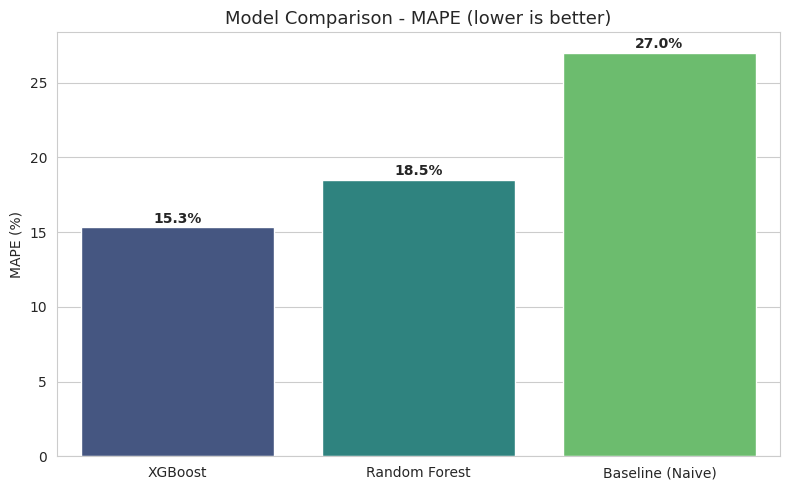

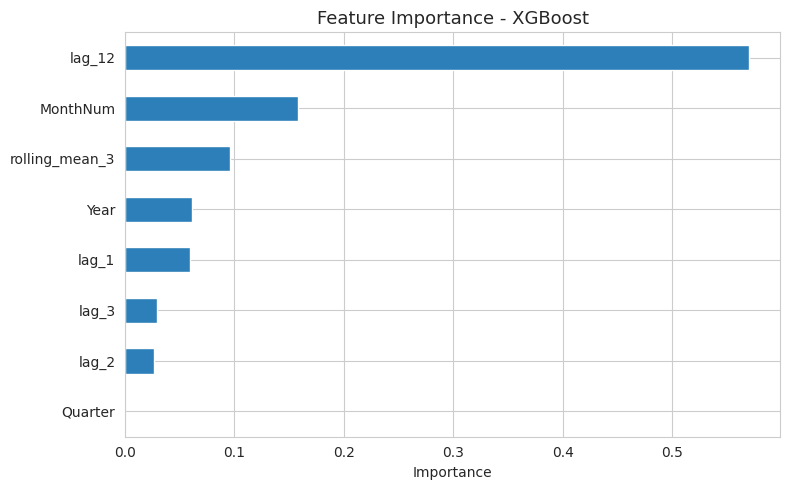

In [12]:
# ---------- Build a clean comparison table ----------
results_df = (
    pd.DataFrame(results)
      .drop_duplicates(subset="Model", keep="last")   # safe even if cells are re-run
      .sort_values("MAPE")
      .reset_index(drop=True)
)
print("MODEL COMPARISON (best to worst):")
display(results_df.round({"MAE": 0, "RMSE": 0, "MAPE": 1}))

# ---------- Chart 1: Compare models by MAPE ----------
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="MAPE",
            hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison - MAPE (lower is better)")
plt.ylabel("MAPE (%)")
plt.xlabel("")
for i, v in enumerate(results_df["MAPE"]):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/05_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- Chart 2: Feature importance of the best model ----------
best_name  = results_df.iloc[0]["Model"]
best_model = xgb_model if "XGBoost" in best_name else rf_model

importances = pd.Series(best_model.feature_importances_,
                        index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#2c7fb8")
plt.title(f"Feature Importance - {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/06_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 13 - Forecasting the Future

Now the real goal: predict sales for the **next 6 months** (Jan–Jun 2018),
beyond the end of our data.

This requires **recursive forecasting**. Future months don't have known lag
values yet, so we predict one month at a time and feed each prediction back in
as the input for the next month. We also **retrain the best model on all 36
rows** first - for a real production forecast, you use every bit of data you
have, not just the training split.

In [13]:
from sklearn.base import clone

# ---------- Retrain the best model on ALL available data ----------
final_model = clone(best_model)
final_model.fit(X, y)
print(f"Final model ({best_name}) retrained on all {len(X)} months.\n")

# ---------- Recursive 6-month forecast ----------
N_FUTURE = 6
history = monthly_sales.set_index("Month")["Sales"].copy()  # full 48-month history
last_date = history.index.max()
future_rows = []

for i in range(1, N_FUTURE + 1):
    next_date = last_date + pd.DateOffset(months=i)
    row = {
        "Year": next_date.year,
        "MonthNum": next_date.month,
        "Quarter": next_date.quarter,
        "lag_1": history.iloc[-1],     # most recent month
        "lag_2": history.iloc[-2],
        "lag_3": history.iloc[-3],
        "lag_12": history.loc[next_date - pd.DateOffset(months=12)],  # same month last year
        "rolling_mean_3": history.iloc[-3:].mean(),
    }
    X_next = pd.DataFrame([row])[feature_cols]
    pred = final_model.predict(X_next)[0]
    history.loc[next_date] = pred          # feed prediction back in for the next step
    future_rows.append({"Month": next_date, "Predicted_Sales": pred})

future_df = pd.DataFrame(future_rows)
future_df["Predicted_Sales"] = future_df["Predicted_Sales"].round(0)
print("6-Month Sales Forecast (Jan–Jun 2018):")
display(future_df)
print(f"Total forecasted sales (next 6 months): ${future_df['Predicted_Sales'].sum():,.0f}")

Final model (XGBoost) retrained on all 36 months.

6-Month Sales Forecast (Jan–Jun 2018):


,Month,Predicted_Sales
0,2018-01-01,58344.0
1,2018-02-01,21435.0
2,2018-03-01,57649.0
3,2018-04-01,34421.0
4,2018-05-01,45193.0
5,2018-06-01,41935.0


Total forecasted sales (next 6 months): $258,977


## Phase 14 - Final Forecast Visualization

This is the chart you'd present to a business. It shows three things on one
timeline:

- **Actual sales** - the real history (2014–2017).
- **Test predictions** - how closely the model tracked the unseen 6-month test
  period (the proof it works).
- **Future forecast** - the predicted next 6 months, with the forecast region
  shaded.

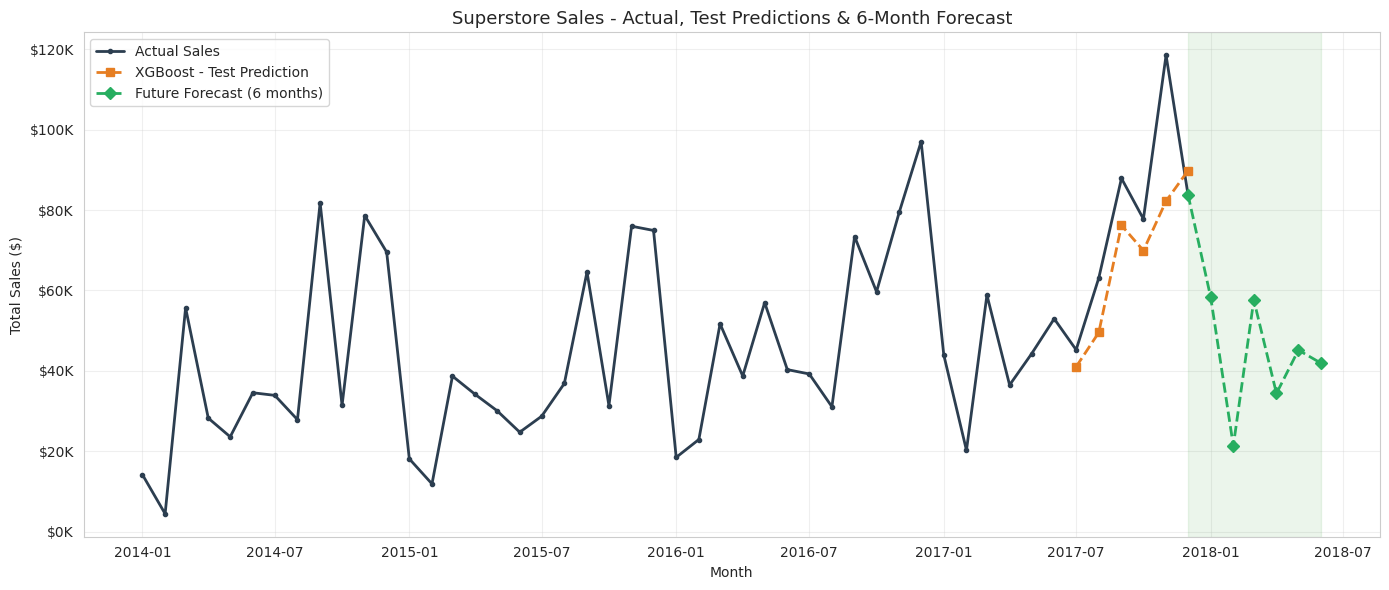

In [14]:
from matplotlib.ticker import FuncFormatter

best_pred = xgb_pred if "XGBoost" in best_name else rf_pred

plt.figure(figsize=(14, 6))

# Actual history
plt.plot(monthly_sales["Month"], monthly_sales["Sales"],
         label="Actual Sales", color="#2c3e50", linewidth=2, marker="o", markersize=3)

# Test-set predictions (validation)
plt.plot(test_dates, best_pred,
         label=f"{best_name} - Test Prediction", color="#e67e22",
         linewidth=2, linestyle="--", marker="s")

# Future forecast (connected to the last actual point for a continuous line)  # <-- CHANGED
last_actual = (monthly_sales.iloc[[-1]]
               .rename(columns={"Sales": "Predicted_Sales"})[["Month", "Predicted_Sales"]])
forecast_plot = pd.concat([last_actual, future_df], ignore_index=True)
plt.plot(forecast_plot["Month"], forecast_plot["Predicted_Sales"],
         label="Future Forecast (6 months)", color="#27ae60",
         linewidth=2, linestyle="--", marker="D")

# Shade the future region
plt.axvspan(monthly_sales["Month"].max(), future_df["Month"].max(),
            alpha=0.08, color="green")

plt.title("Superstore Sales - Actual, Test Predictions & 6-Month Forecast", fontsize=13)
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))   # <-- NEW ($ axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/07_final_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
import plotly.graph_objects as go

fig = go.Figure()

# Actual sales
fig.add_trace(go.Scatter(
    x=monthly_sales["Month"], y=monthly_sales["Sales"],
    mode="lines+markers", name="Actual Sales",
    line=dict(color="#2c3e50", width=2)))

# Test-set predictions
fig.add_trace(go.Scatter(
    x=test_dates, y=best_pred,
    mode="lines+markers", name=f"{best_name} - Test Prediction",
    line=dict(color="#e67e22", width=2, dash="dash")))

# Future forecast (connected to last actual)
fig.add_trace(go.Scatter(
    x=forecast_plot["Month"], y=forecast_plot["Predicted_Sales"],
    mode="lines+markers", name="Future Forecast (6 months)",
    line=dict(color="#27ae60", width=2, dash="dash")))

fig.update_layout(
    title="Superstore Sales - Interactive Forecast",
    xaxis_title="Month", yaxis_title="Total Sales ($)",
    hovermode="x unified", template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.update_yaxes(tickprefix="$", tickformat=",.0f")

# Save a standalone interactive HTML for the repo (openable in any browser)
fig.write_html(f"{PROJECT}/reports/figures/interactive_forecast.html")
fig.show()

## Phase 15 - Business Insights & Takeaways

### What the forecast tells us
The model predicts sales of roughly **$259,000 over the next 6 months
(Jan–Jun 2018)** - in line with the same period the previous year. Crucially, it
reproduces the real seasonal pattern: a strong January, a sharp **February dip
(~$21K)**, and a March recovery.

### Key business insights
1. **Sales are growing year-over-year** (2014 → 2017), so the business should
   plan for continued, gradual growth.
2. **Seasonality is strong and reliable.** Sales peak in Q4 (Sep, Nov, Dec) and
   bottom out in February every year - the model's top signal is literally
   "same month last year" (`lag_12`).
3. **The West region and Technology category drive the most revenue** - prime
   focus areas for inventory and marketing spend.
4. **Heavy discounts hurt profit** - some orders run at a loss. Discounting on
   loss-making sub-categories deserves review.

### Recommended business actions
- **Stock up inventory and staffing before Q4** to capture the seasonal peak.
- **Run promotions or reduce inventory in February** (the predictable slow month).
- **Prioritize the West region and Technology line** in growth planning.

### Model reliability (honest note)
The best model (XGBoost) achieves **~15% MAPE**, meaning forecasts are within
about 15% of actuals on average - solid for business planning. Limitation: only
4 years of data are available, and recursive multi-step forecasts grow less
certain further out, so this is a planning guide, not a guarantee.

In [16]:
# ---------- Save the future forecast ----------
future_df.to_csv(f"{PROJECT}/data/processed/future_forecast.csv", index=False)
print("Saved -> data/processed/future_forecast.csv")

# ---------- List all generated figures ----------
print("\nFigures saved in reports/figures/:")
for fig in sorted(os.listdir(f"{PROJECT}/reports/figures")):
    print("  -", fig)

# ---------- Zip the whole project folder (keeps the FUTURE_ML_01 top folder) ----------
shutil.make_archive(base_name=PROJECT, format="zip", root_dir=".", base_dir=PROJECT)
print(f"\nProject zipped -> {PROJECT}.zip")

# ---------- Download to your computer ----------
from google.colab import files
files.download(f"{PROJECT}.zip")

Saved -> data/processed/future_forecast.csv

Figures saved in reports/figures/:
  - 01_sales_trend.png
  - 02_seasonality.png
  - 03_sales_by_segment.png
  - 04_decomposition.png
  - 05_model_comparison.png
  - 06_feature_importance.png
  - 07_final_forecast.png
  - interactive_forecast.html

Project zipped -> FUTURE_ML_01.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>